In [9]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import matplotlib.pyplot as plt

In [3]:
fsm2 = xr.open_dataset("../data/FSM2/fsm2_sd_2023.nc")
print(fsm2)

<xarray.Dataset> Size: 3GB
Dimensions:      (time: 365, y: 1550, x: 1195)
Coordinates:
  * time         (time) datetime64[ns] 3kB 2023-01-01 2023-01-02 ... 2023-12-31
  * y            (y) float64 12kB 6.45e+06 6.451e+06 ... 7.998e+06 7.999e+06
  * x            (x) float64 10kB -7.5e+04 -7.4e+04 ... 1.118e+06 1.119e+06
    lon          (y, x) float64 15MB ...
    lat          (y, x) float64 15MB ...
Data variables:
    snow_depth   (time, y, x) float32 3GB ...
    UTM_Zone_33  float64 8B ...
Attributes:
    title:        Snow depth
    institution:  NVE
    source:       ConvertTo-Grid
    history:      Initial
    references:   http://www.xgeo.no/
    comment:      Snow depth simulated by the FSM2 model run at NVE and force...
    Conventions:  CF-1.6


In [4]:
fsm2 = xr.open_dataset("../data/FSM2/fsm2_sd_2023.nc")

print(fsm2["snow_depth"].attrs)

{'Name': 'snow_depth', 'grid_mapping': 'UTM_Zone_33', 'name': 'snow_depth', 'units': 'mm', 'standard_name': 'snow_depth', 'longname': 'snow depth'}


/var/folders/4n/m1gxpf611c158s8wx2jzfqgw0000gn/T/ipykernel_2595/2185637725.py:1: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  sd_mid = fsm2["snow_depth"].isel(y=fsm2.dims["y"]//2, x=fsm2.dims["x"]//2)


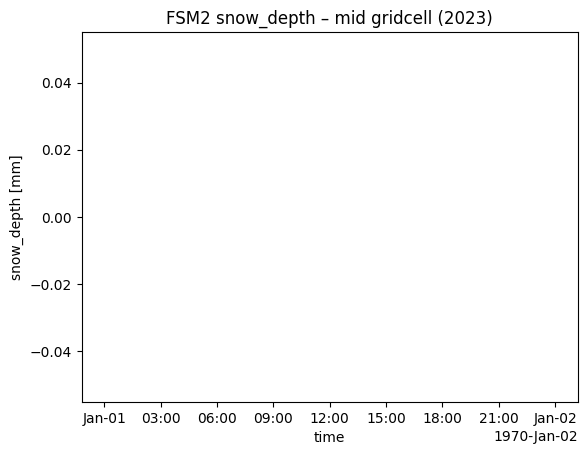

In [5]:
sd_mid = fsm2["snow_depth"].isel(y=fsm2.dims["y"]//2, x=fsm2.dims["x"]//2)

sd_mid.plot()
plt.title("FSM2 snow_depth – mid gridcell (2023)")
plt.show()

In [6]:
sd_mid = fsm2["snow_depth"].isel(y=fsm2.sizes["y"]//2, x=fsm2.sizes["x"]//2)

print(sd_mid.isnull().mean().item())   # andel NaN
print(sd_mid.min().item(), sd_mid.max().item())
print(sd_mid.time.values[:3], sd_mid.time.values[-3:])

1.0
nan nan
['2023-01-01T00:00:00.000000000' '2023-01-02T00:00:00.000000000'
 '2023-01-03T00:00:00.000000000'] ['2023-12-29T00:00:00.000000000' '2023-12-30T00:00:00.000000000'
 '2023-12-31T00:00:00.000000000']


Index with max snow: 401 129
Max snow (mm): 10780.0
Lat/Lon: 61.53312725486827 6.596412821402865


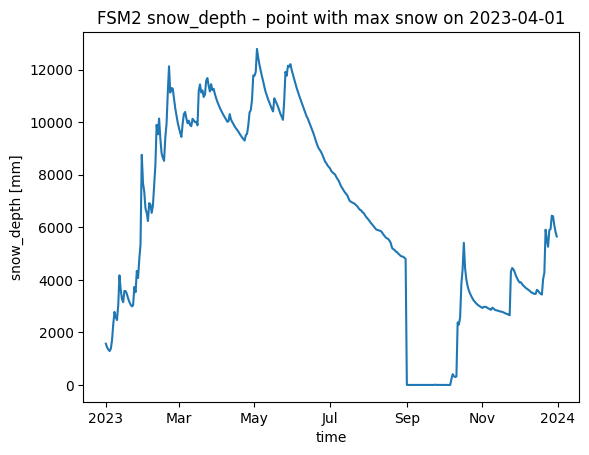

In [7]:
sd_day = fsm2["snow_depth"].sel(time="2023-04-01")

flat_index = np.nanargmax(sd_day.values)
iy, ix = np.unravel_index(flat_index, sd_day.shape)

print("Index with max snow:", iy, ix)
print("Max snow (mm):", float(sd_day.isel(y=iy, x=ix).values))
print("Lat/Lon:", float(fsm2["lat"].isel(y=iy, x=ix).values),
                 float(fsm2["lon"].isel(y=iy, x=ix).values))

sd_pt = fsm2["snow_depth"].isel(y=iy, x=ix)

sd_pt.plot()
plt.title("FSM2 snow_depth – point with max snow on 2023-04-01")
plt.show()

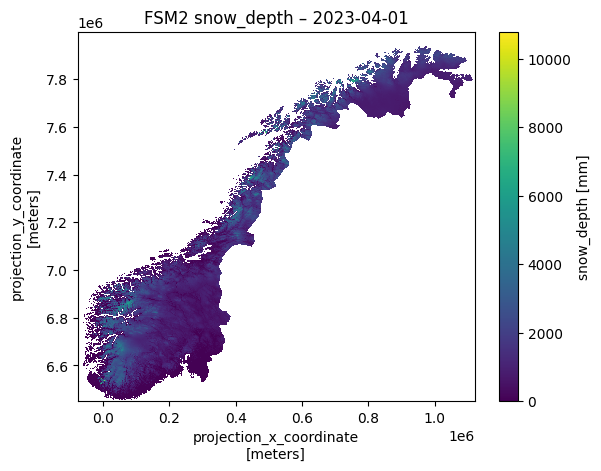

In [8]:
sd_day = fsm2["snow_depth"].sel(time="2023-04-01")
sd_day.plot()
plt.title("FSM2 snow_depth – 2023-04-01")
plt.show()